In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
sales = pd.read_csv("C:/sales_data.csv",engine="python",encoding="latin-1")

In [4]:
sales.head()

,Row ID,Order_ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product_Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order_ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product_Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
sales.isnull().sum()

Row ID           0
Order_ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product_Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
sales["Order Date"] = pd.to_datetime(sales["Order Date"], format="mixed")

In [9]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order_ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

## VISUALIZATION

## Line Chart (Sales Over Time)

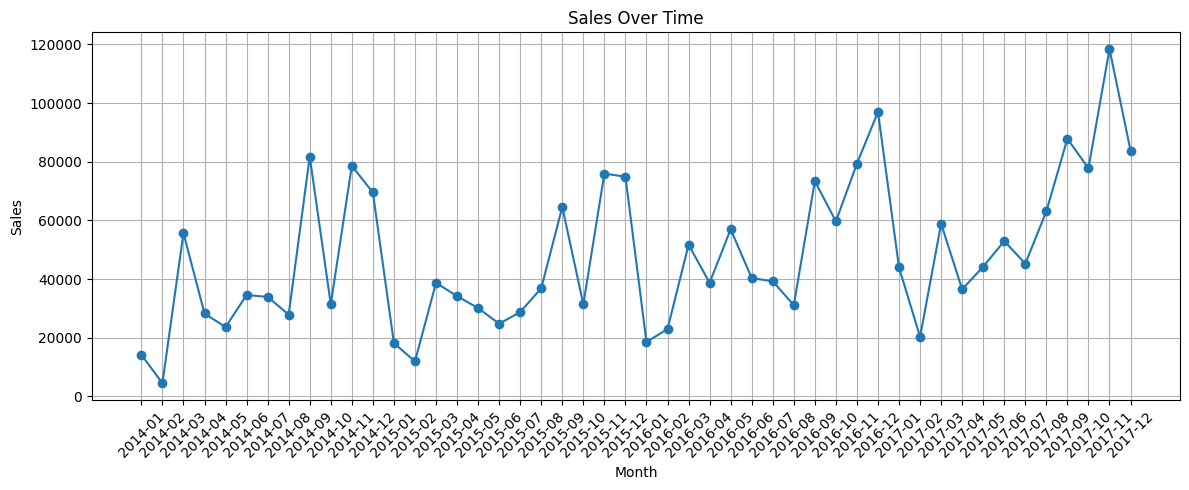

In [18]:
sales_over_time=sales.groupby(sales["Order Date"].dt.to_period("M"))["Sales"].sum()
sales_over_time.index = sales_over_time.index.astype(str)
plt.figure(figsize=(12,5))
plt.plot(sales_over_time, marker='o')
plt.title("Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)        
plt.tight_layout()
plt.savefig("line_chart_sales_over_time.png")
plt.show()

## monthly sales

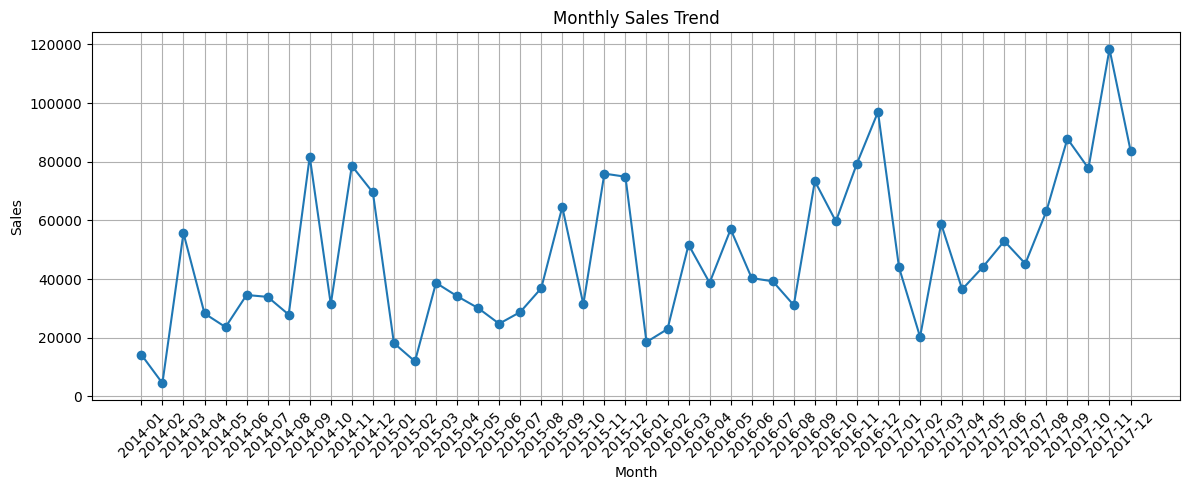

In [13]:
monthly_sales=sales.groupby(sales["Order Date"].dt.to_period("M"))["Sales"].sum()
monthly_sales.index=monthly_sales.index.astype(str)
plt.figure(figsize=(12,5))
plt.plot(monthly_sales, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("monthly_sales.png")
plt.show()

## quarterly sales

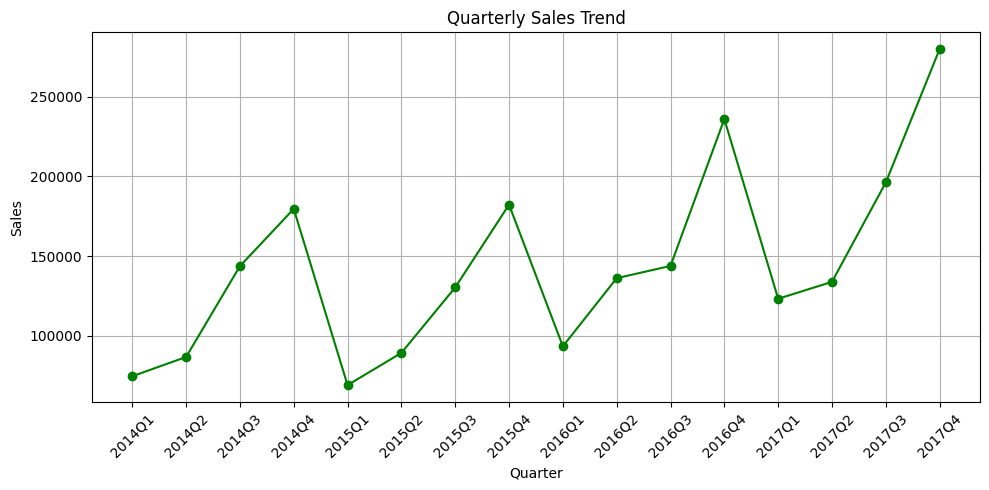

In [14]:
quarterly_sales=sales.groupby(sales["Order Date"].dt.to_period("Q"))["Sales"].sum()
quarterly_sales.index=quarterly_sales.index.astype(str)
plt.figure(figsize=(10,5))
plt.plot(quarterly_sales, marker='o', color='green')
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("quarterly_sales.png")
plt.show()

## BAR CHART Category Comparison

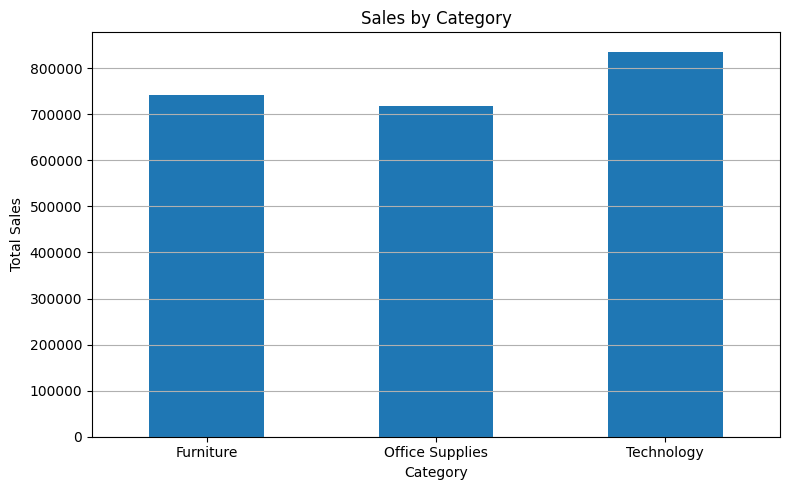

In [22]:
category_sales=sales.groupby("Category")["Sales"].sum()
plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("bar_chart_category_comparison.png")
plt.show()

## Technology category generates the highest sales compared to Furniture and Office Supplies.

## PIE CHART Share of Sales

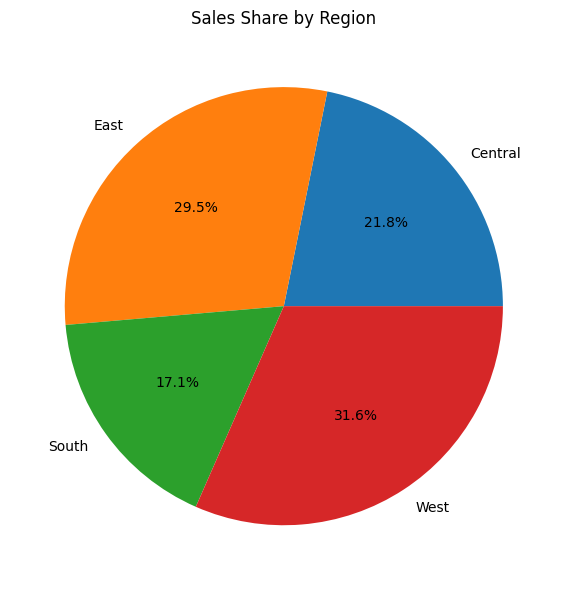

In [16]:
share_of_sales=sales.groupby("Region")["Sales"].sum()
plt.figure(figsize=(6,6))
share_of_sales.plot(kind="pie", autopct="%1.1f%%")
plt.title("Sales Share by Region")
plt.ylabel("")
plt.tight_layout()
plt.savefig("pie_chart_share_of_sales.png")
plt.show()

## summary

In [1]:
summary = """
This project analyzes retail sales data using various visualization techniques.
Monthly and quarterly line charts show sales trends over time, indicating fluctuations and overall growth.
Bar charts reveal that the Technology category has the highest sales compared to other categories.
Pie charts show that certain regions contribute more significantly to total sales.
Overall, different visualizations help understand trends, comparisons, and proportions effectively.
"""
with open("summary.txt", "w") as f:
    f.write(summary)
print(summary)


This project analyzes retail sales data using various visualization techniques.
Monthly and quarterly line charts show sales trends over time, indicating fluctuations and overall growth.
Bar charts reveal that the Technology category has the highest sales compared to other categories.
Pie charts show that certain regions contribute more significantly to total sales.
Overall, different visualizations help understand trends, comparisons, and proportions effectively.



## Chart Selection and Formatting Explanation

Different chart types were selected based on the nature of the data and the type of insight required.
A line chart was used to visualize sales over time because it effectively shows trends and patterns across months and quarters. It helps identify fluctuations and overall growth in sales.
A bar chart was used to compare sales across product categories, as it provides a clear comparison between discrete groups and makes it easy to identify the highest and lowest performing categories.
A pie chart was used to represent the proportion of sales by region, as it is suitable for showing percentage distribution and relative contribution.
Proper formatting was applied to improve readability and clarity. Titles were added to describe each chart clearly. Axis labels were included to indicate what each axis represents. X-axis labels were rotated where necessary to avoid overlap. Grid lines were used in line and bar charts to make values easier to interpret. Legends and labels help in understanding the data without confusion.
Overall, each chart type and formatting choice was made to ensure the data is presented clearly and insights can be easily understood.